# Notebook 01: Vectorstore Build

## Goal

Chunk all 18 medical textbooks, embed with Qwen3-Embedding-0.6B, and persist a FAISS index to disk.

This notebook runs **once**. After it completes, all RAG queries load the saved index in seconds.

**Output:**
```
models/vectorstore/
  index.faiss     ← FAISS IndexFlatIP (exact cosine)
  metadata.pkl    ← one dict per chunk {book, friendly_name, chunk_idx}
  texts.pkl       ← raw chunk strings, parallel to index vectors
  config.json     ← build settings for reproducibility
```

**Expected runtime:** ~5–10 min on Colab T4 GPU, ~30–45 min on CPU.

## 0. Setup

In [1]:
# Imports
import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_textbook, load_all_textbooks, REPO_ROOT
from src.vectorstore import (
    BIOMEDICAL_MODEL,
    CHUNK_SIZE,
    CHUNK_OVERLAP,
    QUERY_INSTRUCTION,
    VECTORSTORE_DIR,
    chunk_text,
    chunk_all_textbooks,
    load_embedding_model,
    embed_texts,
    build_faiss_index,
    save_index_with_texts,
    load_index_with_texts,
    search,
    build_index,
)

print(f'Repo root   : {REPO_ROOT}')
print(f'Model       : {BIOMEDICAL_MODEL}')
print(f'Chunk size  : {CHUNK_SIZE} words  |  Overlap: {CHUNK_OVERLAP} words')
print(f'Output dir  : {VECTORSTORE_DIR}')

Repo root   : C:\uO\Academics\2026_01_Winter\DTI_5125\group\final
Model       : Qwen/Qwen3-Embedding-0.6B
Chunk size  : 400 words  |  Overlap: 50 words
Output dir  : C:\uO\Academics\2026_01_Winter\DTI_5125\group\final\models\vectorstore


## 1. Chunking preview

Sanity-check the word-level chunking before committing to the full build.

In [2]:
# Inspect chunks from Harrison's (largest book)
harrison = load_textbook('InternalMed_Harrison')
chunks = chunk_text(harrison)

print(f'Harrison total chars : {len(harrison):,}')
print(f'Harrison chunk count : {len(chunks):,}')
print(f'\n── Chunk 0 (first {CHUNK_SIZE} words) ──')
print(chunks[0][:400])
print(f'\n── Overlap check: last 10 words of chunk 0 / first 10 of chunk 1 ──')
print('end of 0:', ' '.join(chunks[0].split()[-10:]))
print('start of 1:', ' '.join(chunks[1].split()[:10]))

[Textbook] Loaded 'Harrison's Internal Medicine'  (22,312,859 chars)
Harrison total chars : 22,312,859
Harrison chunk count : 9,161

── Chunk 0 (first 400 words) ──
xxxviii its related products in new formats. Kim Davis, as Associate Managing We are privileged to have compiled this 19th edition and areEditor, has adeptly ensured that the complex production of this multi-enthusiastic about all that it offers our readers. We learned much in the authored textbook proceeded smoothly and efficiently. Dominik Pucek process of editing Harrison’s and hope that you wi

── Overlap check: last 10 words of chunk 0 / first 10 of chunk 1 ──
end of 0: the foundation for the solution to many clinical problems. Spectacular
start of 1: that despite more than 60 years of scientific advances since


In [3]:
# Chunk stats across ALL 18 textbooks (no embedding — fast)
texts, metadata = chunk_all_textbooks()

meta_df = pd.DataFrame(metadata)
book_stats = (
    meta_df.groupby('friendly_name')
    .size()
    .reset_index(name='n_chunks')
    .sort_values('n_chunks', ascending=False)
)
print(f'\nTotal chunks across all books: {len(texts):,}')
print(book_stats.to_string(index=False))

Chunking textbooks: 100%|██████████| 18/18 [00:01<00:00, 11.25it/s]


[Vectorstore] Total chunks: 36,723 across 18 books

Total chunks across all books: 36,723
               friendly_name  n_chunks
Harrison's Internal Medicine      9161
            Schwartz Surgery      4576
             Adams Neurology      3618
         Williams Obstetrics      2740
          Novak's Gynecology      2332
        Alberts Cell Biology      2157
        Katzung Pharmacology      2088
        Janeway's Immunology      1425
              Ross Histology      1323
           Robbins Pathology      1296
           Nelson Pediatrics      1216
            DSM-5 Psychiatry      1196
             Levy Physiology      1166
              Gray's Anatomy      1007
     Lippincott Biochemistry       583
            First Aid Step 2       418
            First Aid Step 1       257
            Pathoma (Husain)       164


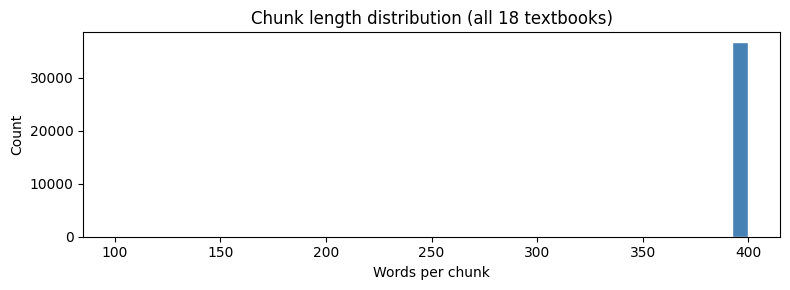

Min: 100  Median: 400  Max: 400


In [4]:
# Chunk length distribution (words)
chunk_lens = [len(t.split()) for t in texts]
plt.figure(figsize=(8, 3))
plt.hist(chunk_lens, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Words per chunk')
plt.ylabel('Count')
plt.title('Chunk length distribution (all 18 textbooks)')
plt.tight_layout()
plt.show()
print(f'Min: {min(chunk_lens)}  Median: {int(np.median(chunk_lens))}  Max: {max(chunk_lens)}')

## 2. Embedding model smoke test

Load Qwen3-Embedding-0.6B and verify the similarity matrix makes medical sense before running the full build.

In [5]:
# Load model (downloads ~1.2 GB on first run)
model = load_embedding_model()
print(f'Embedding dim: {model.get_sentence_embedding_dimension()}')

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[Vectorstore] Embedding model: Qwen/Qwen3-Embedding-0.6B
Embedding dim: 1024


In [6]:
# Cosine similarity sanity check
# Expect: septic shock pairs > septic shock vs aspirin > septic shock vs anatomy
sample_texts = [
    'Septic shock is defined by vasopressor requirement and lactate >2 mmol/L despite fluid resuscitation.',
    'Management of septic shock includes early antibiotics, IV fluids, and norepinephrine as first-line vasopressor.',
    'Myocardial infarction results from plaque rupture causing coronary artery occlusion and myocardial necrosis.',
    'Aspirin irreversibly inhibits COX-1 and COX-2, reducing thromboxane A2 synthesis and platelet aggregation.',
    'The brachial plexus is formed from the ventral rami of C5 through T1 nerve roots.',
]
labels = ['Septic shock def', 'Septic shock tx', 'MI', 'Aspirin', 'Brachial plexus']

sample_emb = embed_texts(sample_texts, model, batch_size=5, show_progress=False)
sim = sample_emb @ sample_emb.T

sim_df = pd.DataFrame(sim.round(3), index=labels, columns=labels)
print('Cosine similarity matrix:')
print(sim_df)
print('\n✓ Expect row 0↔1 (septic shock) > row 0↔2 (MI) > row 0↔4 (anatomy)')

Cosine similarity matrix:
                  Septic shock def  Septic shock tx     MI  Aspirin  \
Septic shock def             0.998            0.735  0.467    0.374   
Septic shock tx              0.735            0.997  0.382    0.428   
MI                           0.467            0.382  1.004    0.528   
Aspirin                      0.374            0.428  0.528    1.007   
Brachial plexus              0.318            0.297  0.445    0.349   

                  Brachial plexus  
Septic shock def            0.318  
Septic shock tx             0.297  
MI                          0.445  
Aspirin                     0.349  
Brachial plexus             1.007  

✓ Expect row 0↔1 (septic shock) > row 0↔2 (MI) > row 0↔4 (anatomy)


## 3. Full build

⚠️ **Run once only.** If `models/vectorstore/index.faiss` already exists, skip to section 4.

**Recommended:** connect to a Colab T4 GPU via the Google Colab VS Code extension before running this cell (5–10 min vs 30–45 min on CPU).

In [ ]:
# ── COLAB ONLY: run this cell once to set up the environment ─────────────────
# Uncomment and fill in your repo URL, then run before the recovery cell above.
# Skip entirely if running locally.
# ─────────────────────────────────────────────────────────────────────────────

import os

# 1. Clone your repo (or mount Google Drive if you uploaded it there)
!git clone https://github.com/jaxendutta/emma.git
os.chdir('/content/emma')          # make repo root the working directory

# 2. Install the package and dependencies
!pip install -e . -q              # installs src/ as 'emma' package
!pip install faiss-cpu sentence-transformers -q

# 3. Verify GPU
!nvidia-smi | head -20


In [8]:
# ── Colab / fresh-kernel recovery ────────────────────────────────────────────
# If you're running this cell on a Colab T4 (or any fresh kernel that didn't
# run sections 1–2), this cell re-establishes everything needed for the build.
#
# ON COLAB: also run the two shell cells below this one first to
#   (a) clone/mount your repo, and (b) install dependencies.
# ON LOCAL (fresh kernel): just run this cell — src/ is already installed.
# ─────────────────────────────────────────────────────────────────────────────
import sys, importlib
from pathlib import Path

# Re-import everything in case this is a fresh kernel
try:
    VECTORSTORE_DIR  # already defined — sections 1-2 were run, nothing to do
    print('Kernel state intact — all variables already defined.')
except NameError:
    print('Fresh kernel detected — re-importing...')
    import json, pickle, time
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from src.data import load_textbook, load_all_textbooks, REPO_ROOT
    from src.vectorstore import (
        BIOMEDICAL_MODEL, CHUNK_SIZE, CHUNK_OVERLAP,
        QUERY_INSTRUCTION, VECTORSTORE_DIR,
        chunk_text, chunk_all_textbooks,
        load_embedding_model, embed_texts,
        build_faiss_index, save_index_with_texts,
        load_index_with_texts, search, build_index,
    )
    print(f'  Repo root : {REPO_ROOT}')
    print(f'  Output dir: {VECTORSTORE_DIR}')
    print(f'  Model     : {BIOMEDICAL_MODEL}')
    print('Re-import complete.')


Kernel state intact — all variables already defined.


In [9]:
index_path = VECTORSTORE_DIR / 'index.faiss'

if index_path.exists():
    print(f'Index already exists at {index_path}')
    print('Skipping build — jump to section 4.')
else:
    t0 = time.time()
    build_index()
    elapsed = time.time() - t0
    print(f'\nBuild time: {elapsed/60:.1f} min')

 EMMA vectorstore build


Chunking textbooks: 100%|██████████| 18/18 [00:01<00:00,  9.43it/s]



[Vectorstore] Total chunks: 36,723 across 18 books


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[Vectorstore] Embedding model: Qwen/Qwen3-Embedding-0.6B

[Vectorstore] Embedding 36,723 chunks (batch_size=64)…


Batches:   0%|          | 0/574 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 4. Verify: load and query

In [ ]:
# Load everything from disk in one call
index, metadata, texts = load_index_with_texts()
print(f'Index vectors : {index.ntotal:,}')
print(f'Chunk texts   : {len(texts):,}')
print(f'Metadata rows : {len(metadata):,}')

In [ ]:
# Query 1: emergency medicine
q = 'What are the clinical features and emergency management of anaphylaxis?'
results = search(q, index, metadata, texts, model, k=5)

print(f'Query: "{q}"\n')
for r in results:
    print(f"Rank {r['rank']}  score={r['score']:.4f}  [{r['friendly_name']}]  chunk {r['chunk_idx']}")
    print(r['text'][:300])
    print()

In [ ]:
# Query 2: USMLE-style clinical vignette
q = '58-year-old man with crushing chest pain radiating to left arm, diaphoresis, ST elevation in II III aVF. Diagnosis and management?'
results = search(q, index, metadata, texts, model, k=5)

print(f'Query: inferior STEMI vignette\n')
for r in results:
    print(f"Rank {r['rank']}  score={r['score']:.4f}  [{r['friendly_name']}]")
    print(r['text'][:300])
    print()

In [ ]:
# Query 3: pharmacology
q = 'mechanism of action of beta blockers in heart failure and their side effects'
results = search(q, index, metadata, texts, model, k=5)

print(f'Query: "{q}"\n')
for r in results:
    print(f"Rank {r['rank']}  score={r['score']:.4f}  [{r['friendly_name']}]")
    print(r['text'][:300])
    print()

## 5. Book coverage analysis

For a diverse set of queries, which books does retrieval draw from? Good retrieval should pull from domain-appropriate sources.

In [ ]:
# Coverage across 8 medical domains
test_queries = {
    'Sepsis':       'Septic shock pathophysiology and vasopressor management',
    'Cardiology':   'STEMI diagnosis ECG changes and reperfusion therapy',
    'Pharmacology': 'ACE inhibitor mechanism hypertension and renal protection',
    'Neurology':    'Ischaemic stroke tPA eligibility and contraindications',
    'Paediatrics':  'Febrile seizures in children evaluation and management',
    'Immunology':   'T cell receptor signalling and co-stimulatory pathways',
    'Surgery':      'Appendicitis diagnosis laparoscopic vs open appendicectomy',
    'Psychiatry':   'Major depressive disorder DSM-5 diagnostic criteria and treatment',
}

rows = []
for topic, q in test_queries.items():
    for r in search(q, index, metadata, texts, model, k=5):
        rows.append({'topic': topic, 'book': r['friendly_name'], 'score': r['score']})

cov_df = pd.DataFrame(rows)
pivot = cov_df.groupby(['topic', 'book']).size().unstack(fill_value=0)
print('Hits per book per query (top-5 results each):')
print(pivot.to_string())

## 6. Summary

In [ ]:
# Load build config
config = json.loads((VECTORSTORE_DIR / 'config.json').read_text())

meta_df = pd.DataFrame(metadata)
book_chunk_counts = meta_df.groupby('friendly_name').size()
top_book = book_chunk_counts.idxmax()
top_book_n = book_chunk_counts.max()

summary_df = pd.DataFrame([
    {'Item': 'Total chunks',         'Value': f"{index.ntotal:,}"},
    {'Item': 'Number of textbooks',  'Value': str(config['num_books'])},
    {'Item': 'Embedding model',      'Value': config['model_name']},
    {'Item': 'Embedding dim',        'Value': str(model.get_sentence_embedding_dimension())},
    {'Item': 'Chunk size',           'Value': f"{config['chunk_size']} words"},
    {'Item': 'Overlap',              'Value': f"{config['chunk_overlap']} words"},
    {'Item': 'FAISS index type',     'Value': 'IndexFlatIP (exact cosine)'},
    {'Item': 'Largest book',         'Value': f"{top_book}  ({top_book_n:,} chunks)"},
    {'Item': 'Index file',           'Value': str(VECTORSTORE_DIR / 'index.faiss')},
])

display(summary_df)
print('\nNext step: 02_classification.ipynb — specialty classifier on MedQA questions.')